### How well do jobs and skills pay for Data Analysts?

#### Methodology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills.

In [57]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [67]:
df.columns

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

In [ ]:
from sklearn.linear_model import LinearRegression

# Select rows with salary
train = df[df['salary'].notna()]
test = df[df['salary'].isna()]

features = ['experience_level', 'job_title_short', 'job_country']

model = LinearRegression()
model.fit(train[features], train['salary'])

df.loc[df['salary'].isna(), 'salary'] = model.predict(test[features])

In [59]:
df_swe = df[(df['job_country'] == 'Sweden')]#.dropna(subset=['salary_year_avg'])


In [62]:
exchange_rate = 10.61
df_swe['salary_year_avg_sek'] = df_swe['salary_year_avg'] * exchange_rate  

In [63]:
df_swe['salary_year_avg_sek'].isna().sum()

np.int64(0)

<Axes: >

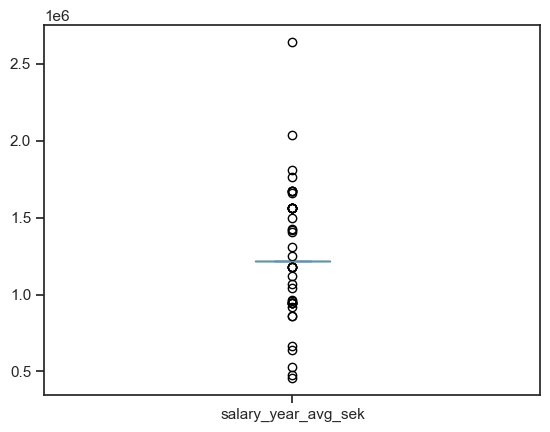

In [64]:
df_swe['salary_year_avg_sek'].plot(kind='box')

<Axes: ylabel='Frequency'>

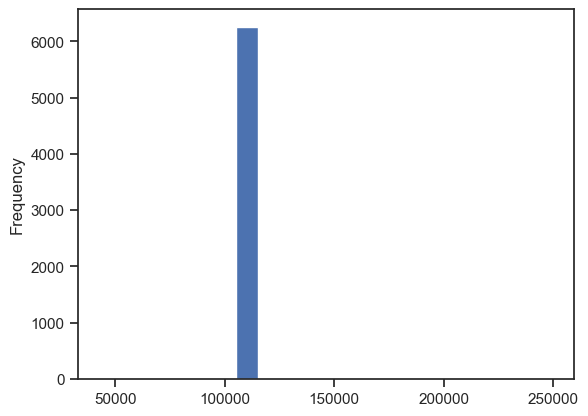

In [ ]:
df_swe['salary_year_avg'].plot(kind='hist', bins)

In [41]:
df_swe.sample(20)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_sek
321385,Business Analyst,Associate Business Analyst,"Linköping, Sweden",via Jobbland,Full-time,False,Sweden,2023-01-27 18:14:28,False,False,Sweden,NaN,89100.0,NaN,Infor,NaN,NaN,945351.000
719832,Data Engineer,DATA ENGINEER SÖKES,"Gothenburg, Sweden",via Trabajo.org,Full-time,False,Sweden,2023-04-15 21:12:24,False,False,Sweden,NaN,133870.5,NaN,Ikaros,"[scala, python, java, r, aws, azure, kafka, sp...","{'cloud': ['aws', 'azure'], 'libraries': ['kaf...",1420366.005
722409,Data Scientist,Data Scientist,"Stockholm, Sweden",via Trabajo.org,Full-time,False,Sweden,2023-04-15 21:12:22,False,False,Sweden,NaN,157500.0,NaN,Midasplayer AB,"[sql, r, python, java, hadoop, excel]","{'analyst_tools': ['excel'], 'libraries': ['ha...",1671075.000
515093,Data Engineer,Data Engineer,"Gothenburg, Sweden",via LinkedIn,Full-time,False,Sweden,2023-05-14 11:16:38,True,False,Sweden,NaN,133870.5,NaN,B3 Consulting Group,"[python, sql, spark, hadoop]","{'libraries': ['spark', 'hadoop'], 'programmin...",1420366.005
487989,Data Scientist,Data Science,"Gothenburg, Sweden",via Trabajo.org,Full-time,False,Sweden,2023-09-19 11:19:27,False,False,Sweden,NaN,157500.0,NaN,Combine Control Systems AB,"[python, tensorflow]","{'libraries': ['tensorflow'], 'programming': [...",1671075.000
213788,Senior Data Engineer,Senior Data Engineer,"Solna, Sweden",via Trabajo.org,Full-time,False,Sweden,2023-07-25 22:33:15,False,False,Sweden,NaN,147500.0,NaN,Telia Company,"[scala, sql, aws, gcp, bigquery, spark, github...","{'cloud': ['aws', 'gcp', 'bigquery'], 'librari...",1564975.000
690029,Business Analyst,Test Analyst Trading Services,"Solna, Sweden",via Trabajo.org,Full-time,False,Sweden,2023-08-04 10:19:14,True,False,Sweden,NaN,89100.0,NaN,Skandinaviska Enskilda Banken AB,"[sql, jira]","{'async': ['jira'], 'programming': ['sql']}",945351.000
261827,Machine Learning Engineer,Machine Learning Engineer,"Stockholm, Sweden",via LinkedIn,Full-time,False,Sweden,2023-09-29 07:21:26,False,False,Sweden,NaN,141000.0,NaN,Folksam,"[python, scala, r, azure, databricks, spark, g...","{'cloud': ['azure', 'databricks'], 'libraries'...",1496010.000
206725,Senior Data Scientist,Senior Data Scientist,"Stockholm, Sweden",via SimplyHired,Full-time,False,Sweden,2023-07-04 22:29:35,False,False,Sweden,NaN,170500.0,NaN,Venquis,NaN,NaN,1809005.000
551108,Data Scientist,Chief Data Scientist,Sweden,via Trabajo.org,Full-time,False,Sweden,2023-06-06 19:18:11,False,False,Sweden,NaN,157500.0,NaN,Datatera AB,NaN,NaN,1671075.000


In [42]:
job_titles = df_swe['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Scientist',
 'Data Analyst',
 'Software Engineer',
 'Business Analyst',
 'Senior Data Engineer']

In [43]:
df_swe_top6 = df_swe[df_swe['job_title_short'].isin(job_titles)]

In [44]:
job_order = df_swe_top6.groupby('job_title_short')['salary_year_avg_sek'].median().sort_values(ascending=False).index

In [45]:
df_swe_top6.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_avg_sek
213,Software Engineer,Product Analyst,Anywhere,via LinkedIn,Full-time,True,Sweden,2023-07-07 13:38:09,False,False,Sweden,NaN,156500.0,NaN,ZERO Systems,"[outlook, excel, word, powerpoint, power bi, t...","{'analyst_tools': ['outlook', 'excel', 'word',...",1660465.0
312,Data Scientist,Analytics Engineer,"Stockholm, Sweden",via LinkedIn,Full-time,False,Sweden,2023-03-09 13:38:35,True,False,Sweden,NaN,157500.0,NaN,Epidemic Sound,"[sql, python, bigquery, snowflake, gcp, aws, a...","{'analyst_tools': ['looker'], 'cloud': ['bigqu...",1671075.0
432,Data Analyst,Full Time / Entry Level - Research Data Analys...,Anywhere,via LinkedIn,Full-time,True,Sweden,2023-01-30 13:30:53,False,False,Sweden,NaN,105650.0,NaN,REMOTE JOBS WORK FROM HOME,"[r, python, sql]","{'programming': ['r', 'python', 'sql']}",1120946.5
529,Data Analyst,Business Data Analyst/Contarctor,"Solna, Sweden",via SimplyHired,Full-time,False,Sweden,2023-10-26 13:23:35,True,False,Sweden,NaN,105650.0,NaN,Telia Company,"[sql, sas, sas, aws, redshift, sap]","{'analyst_tools': ['sas', 'sap'], 'cloud': ['a...",1120946.5
560,Software Engineer,Full Stack Engineer,"Tyresö, Sweden",via Trabajo.org,Full-time,False,Sweden,2023-01-21 13:39:50,False,False,Sweden,NaN,156500.0,NaN,owision AB,"[java, sql, nosql, mongodb, mongodb, python, c...","{'databases': ['mongodb', 'postgresql', 'mysql...",1660465.0


In [46]:

df_swe['salary_year_avg_sek'].mean()
#df_swe['salary_year_avg_sek'].max()

np.float64(1423500.791887002)

<Axes: ylabel='Frequency'>

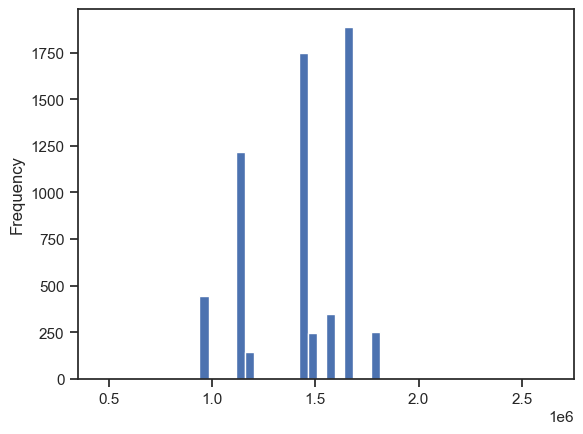

In [47]:
df_swe['salary_year_avg_sek'].plot(kind='hist', bins=50)

<Axes: xlabel='salary_year_avg_sek', ylabel='job_title_short'>

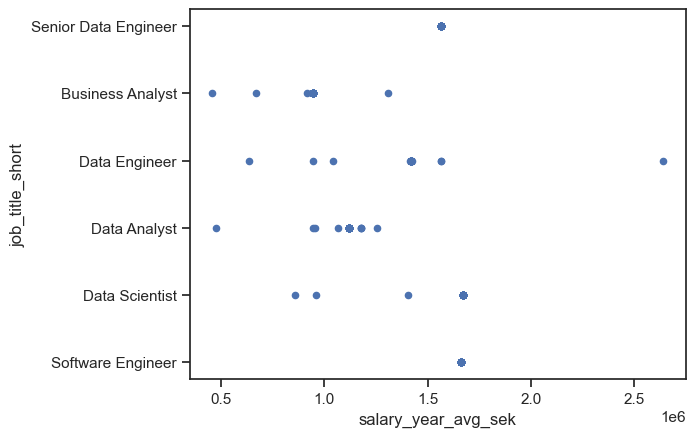

In [48]:
df_swe_top6.plot(kind='scatter',x='salary_year_avg_sek', y='job_title_short')

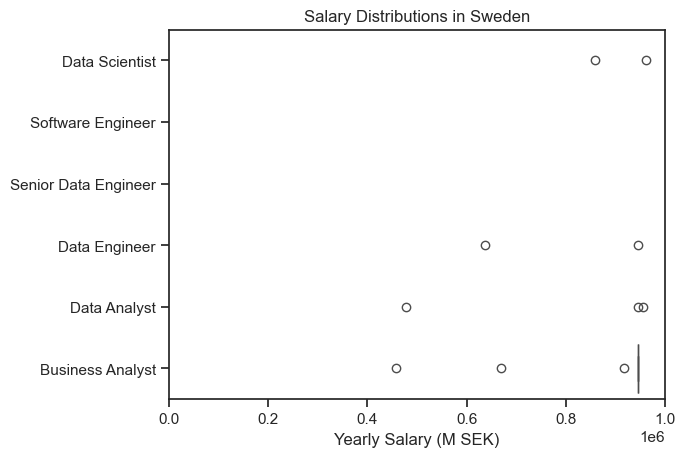

In [49]:
sns.boxplot(data=df_swe_top6, x='salary_year_avg_sek', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distributions in Sweden')
plt.xlabel('Yearly Salary (M SEK)')
plt.ylabel('')
plt.xlim(0,1000000)
# ticks_x = plt.FuncFormatter(lambda y, pos: f'{int(y/1000000)}')
# plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

## Investigating Median Salary Vs Skill for Data Analysts

In [50]:
df_da_swe = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Sweden')].copy()

df_da_swe = df_da_swe.dropna(subset=['salary_year_avg'])

df_da_swe['salary_year_avg_sek'] = df_swe['salary_year_avg'] * exchange_rate


In [51]:
df_da_swe.info()

<class 'pandas.DataFrame'>
Index: 946 entries, 432 to 785184
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        946 non-null    str           
 1   job_title              946 non-null    str           
 2   job_location           946 non-null    str           
 3   job_via                946 non-null    str           
 4   job_schedule_type      945 non-null    str           
 5   job_work_from_home     946 non-null    bool          
 6   search_location        946 non-null    str           
 7   job_posted_date        946 non-null    datetime64[us]
 8   job_no_degree_mention  946 non-null    bool          
 9   job_health_insurance   946 non-null    bool          
 10  job_country            946 non-null    str           
 11  salary_rate            9 non-null      str           
 12  salary_year_avg        946 non-null    float64       
 13  salary_hour_avg 

<Axes: ylabel='Frequency'>

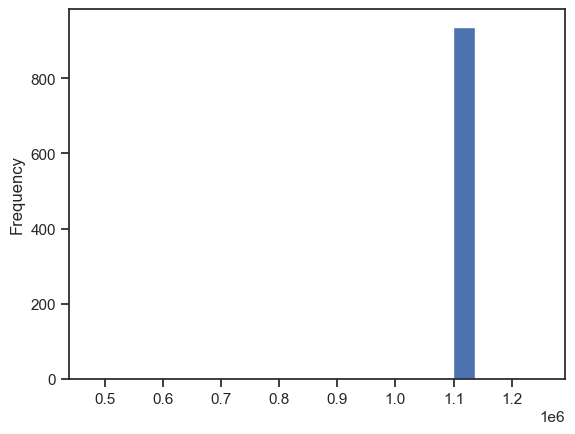

In [52]:
df_da_swe['salary_year_avg_sek'].plot(kind='hist', bins=20)

In [53]:
df_da_swe = df_da_swe.explode('job_skills')

df_da_swe[['salary_year_avg_sek', 'job_skills']].head(5)

,salary_year_avg_sek,job_skills
432,1120946.5,r
432,1120946.5,python
432,1120946.5,sql
529,1120946.5,sql
529,1120946.5,sas


In [54]:
df_da_top_pay = df_da_swe.groupby('job_skills')['salary_year_avg_sek'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_da_top_pay = df_da_top_pay.head(10)

df_da_top_pay


,count,median
job_skills,,
airflow,18,1120946.5
alteryx,8,1120946.5
assembly,4,1120946.5
aws,52,1120946.5
azure,81,1120946.5
bash,4,1120946.5
bigquery,77,1120946.5
bitbucket,1,1120946.5
c,10,1120946.5


In [55]:
df_da_skills = df_da_swe.groupby('job_skills')['salary_year_avg_sek'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_da_skills = df_da_skills.head(10).sort_values(by='median', ascending=False)

df_da_skills

,count,median
job_skills,,
sql,544,1120946.5
python,372,1120946.5
tableau,215,1120946.5
power bi,205,1120946.5
r,187,1120946.5
excel,160,1120946.5
looker,98,1120946.5
sas,92,1120946.5
azure,81,1120946.5


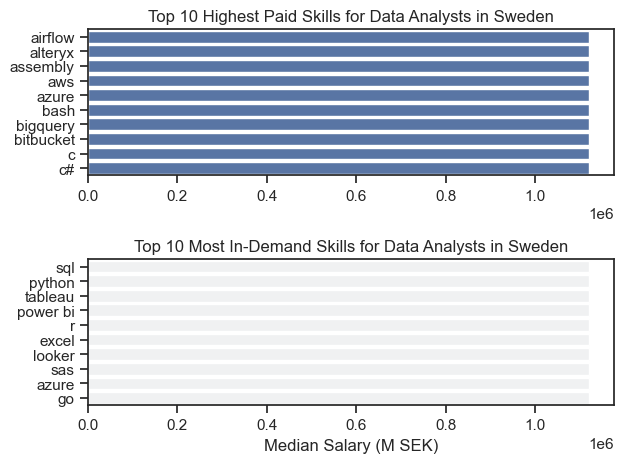

In [56]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style = "ticks")
sns.barplot(data=df_da_top_pay, x='median', y=df_da_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r')

# df_da_top_pay.plot(kind = 'barh', y='median', ax=ax[0], legend = False)
# ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts in Sweden')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
# ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].legend().remove()

# df_da_skills.plot(kind = 'barh', y='median', ax=ax[1], legend = False)

sns.barplot(data=df_da_skills, x='median', y=df_da_skills.index, ax=ax[1], hue='median', palette='light:b')

# ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts in Sweden')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (M SEK)')
# ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
# ax[1].set_xlim(ax[0].get_xlim())
ax[1].legend().remove()
fig.tight_layout()
plt.show()